# Import Data

In [1]:
import pandas as pd

url = "https://media.githubusercontent.com/media/KhalPrawira/Big-Data_Assignment/refs/heads/main/Dataset/Road%20Accident%20Data.csv"
df = pd.read_csv(url)

display(df.head())

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [3]:
unique_weather = df['Weather_Conditions'].unique()
print(unique_weather)

['Fine no high winds' 'Other' 'Raining no high winds'
 'Snowing no high winds' 'Fine + high winds' 'Raining + high winds' nan
 'Snowing + high winds' 'Fog or mist']


In [5]:
unique_road = df['Road_Surface_Conditions'].unique()
print(unique_road)

['Dry' 'Wet or damp' 'Frost or ice' 'Snow' 'Flood over 3cm. deep' nan]


In [6]:
unique_light = df['Light_Conditions'].unique()
print(unique_light)

['Daylight' 'Darkness - lights lit' 'Darkness - lighting unknown'
 'Darkness - lights unlit' 'Darkness - no lighting']


In [7]:
unique_rt = df['Road_Type'].unique()
print(unique_rt)

['One way street' 'Single carriageway' 'Dual carriageway' 'Roundabout'
 'Slip road' nan]


In [9]:
severity_mapping = {'Slight': 1, 'Serious': 2, 'Fatal': 3}
df['Accident_Severity_Numeric'] = df['Accident_Severity'].map(severity_mapping)

print(df['Accident_Severity_Numeric'].value_counts())

Accident_Severity_Numeric
1.0    263280
2.0     40740
3.0      3904
Name: count, dtype: int64


In [13]:
weather_mapping = {'Fine no high winds':1, 'Raining no high winds':2, 'Raining + high winds':3, 'Snowing no high winds':4, 'Snowing + high winds':5, 'Fine + high winds':6, 'fog or mist':7, 'Other':8, 'nan':9}
df['Weather_Numeric'] = df['Weather_Conditions'].map(weather_mapping)

print(df['Weather_Numeric'].unique())
print(df['Weather_Numeric'].value_counts())

[ 1.  8.  2.  4.  6.  3. nan  5.]
Weather_Numeric
1.0    244496
2.0     34877
8.0      8802
4.0      4839
3.0      3526
6.0      3148
5.0       538
Name: count, dtype: int64


In [14]:
road_mapping = {'Dry':1, 'Wet or damp':2, 'Frost or ice':3, 'Snow':4, 'Flood over 3cm. deep':5, 'nan':6}
df['Road_Numeric'] = df['Road_Surface_Conditions'].map(road_mapping)

print(df['Road_Numeric'].unique())
print(df['Road_Numeric'].value_counts())

[ 1.  2.  3.  4.  5. nan]
Road_Numeric
1.0    208967
2.0     81479
3.0     12078
4.0      4758
5.0       374
Name: count, dtype: int64


# Analisis Struktur dan Missing Values

In [ ]:
column_info = []
for column in df.columns:
    column_info.append({'Feature': column, 'Data Count': df[column].count()})

column_info_df = pd.DataFrame(column_info)
display(column_info_df)

In [14]:
print("Shape of the DataFrame:", df.shape)
print("\nData Types:\n", df.dtypes)

missing_values = df.isnull().sum()
print("\nMissing Values per column:\n", missing_values)

print("\nSummary Statistics for Numerical Features:\n", df.describe())

Shape of the DataFrame: (307973, 21)

Data Types:
 Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Carriageway_Hazards            object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Road_Surface_Conditions        object
Road_Type                      object
Speed_limit                     int64
Time                           object
Urban_or_Rural_Area            object
Weather_Conditions             object
Vehicle_Type                   object
dtype: object

Missing Values per column:
 Accident_Index                     0
Accident Date                      0
Day_of_Week                       

# Drop fitur dengan missing value

In [15]:
# Identify columns with missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Drop all columns with at least one missing value
cols_to_drop = cols_with_missing
df_dropped = df.drop(columns=cols_to_drop)

print(f"Dropped column(s): {cols_to_drop}")
print("Shape of the DataFrame after dropping columns:", df_dropped.shape)

Dropped column(s): ['Carriageway_Hazards', 'Road_Surface_Conditions', 'Road_Type', 'Time', 'Weather_Conditions']
Shape of the DataFrame after dropping columns: (307973, 16)


In [16]:
print("Shape of the DataFrame:", df_dropped.shape)
print("\nData Types:\n", df_dropped.dtypes)

missing_values = df_dropped.isnull().sum()
print("\nMissing Values per column:\n", missing_values)

print("\nSummary Statistics for Numerical Features:\n", df.describe())

Shape of the DataFrame: (307973, 16)

Data Types:
 Accident_Index                 object
Accident Date                  object
Day_of_Week                    object
Junction_Control               object
Junction_Detail                object
Accident_Severity              object
Latitude                      float64
Light_Conditions               object
Local_Authority_(District)     object
Longitude                     float64
Number_of_Casualties            int64
Number_of_Vehicles              int64
Police_Force                   object
Speed_limit                     int64
Urban_or_Rural_Area            object
Vehicle_Type                   object
dtype: object

Missing Values per column:
 Accident_Index                0
Accident Date                 0
Day_of_Week                   0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Longitude 

# Distribusi Kelas Target

In [17]:
unique_accident_severity = df['Accident_Severity'].unique()
print(unique_accident_severity)

['Serious' 'Slight' 'Fetal' 'Fatal']


In [18]:
accident_severity_counts = df['Accident_Severity'].value_counts()
display(accident_severity_counts)

,count
Accident_Severity,
Slight,263280
Serious,40740
Fatal,3904
Fetal,49


['Serious' 'Slight' 'Fatal']
Accident_Severity
Slight     263280
Serious     40740
Fatal        3953
Name: count, dtype: int64


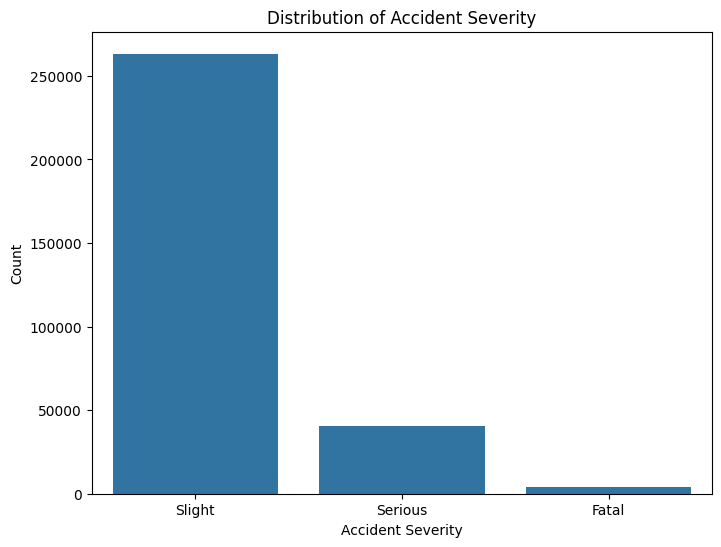

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Accident_Severity'] = df['Accident_Severity'].replace('Fetal', 'Fatal')

# Verify the change
print(df['Accident_Severity'].unique())
print(df['Accident_Severity'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Accident_Severity', order=df['Accident_Severity'].value_counts().index)
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

In [23]:
severity_mapping = {'Slight': 1, 'Serious': 2, 'Fatal': 3}
df['Accident_Severity_Numeric'] = df['Accident_Severity'].map(severity_mapping)

print(df['Accident_Severity_Numeric'].unique())
print(df['Accident_Severity_Numeric'].value_counts())

[2 1 3]
Accident_Severity_Numeric
1    263280
2     40740
3      3953
Name: count, dtype: int64


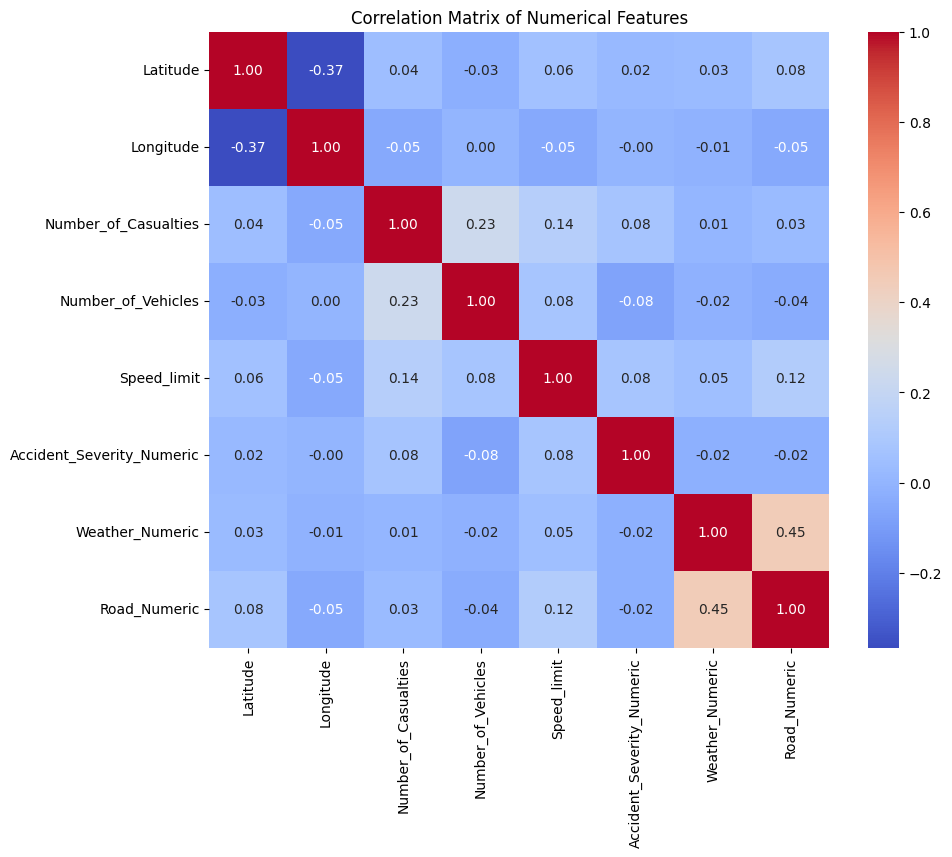

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()